import os
print(os.listdir())

In [2]:
import pandas as pd

xl = pd.ExcelFile('online_retail_II.xlsx')
print(xl.sheet_names)

['Year 2009-2010', 'Year 2010-2011']


## Load both sheets

The data is split into two sheets — one per year. We'll load each one into its own
table, then stack them together into a single table called `df`.

In [3]:
df1 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')
df2 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

##  Check that both sheets loaded correctly

`.shape` tells us (number of rows, number of columns). This is the reliable way to
check size — Jupyter only *displays* a few rows on screen even when a table is huge.

In [4]:

print(df1.shape)
print(df2.shape)

(525461, 8)
(541910, 8)


## Combine both years into one table

`pd.concat` stacks two tables on top of each other. `ignore_index=True` just makes
sure the row numbers restart cleanly from 0 instead of repeating.

In [5]:
df = pd.concat([df1, df2], ignore_index=True)
print(df.shape)

(1067371, 8)


### Take a first look at the data

In [6]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
df.shape

(1067371, 8)

## Clean the data

Real-world data is messy. Before we can trust any analysis, we need to remove:
1. **Cancelled orders** — invoices that start with the letter "C"
2. **Missing Customer ID** — rows where we don't know who made the purchase (guest checkouts), which we can't use for customer-level analysis
3. **Bad Quantity or Price values** — negative or zero values, which represent returns or data errors, not real sales

In [8]:
print("Total rows before cleaning:", df.shape[0])
print("Cancelled invoices:", df['Invoice'].astype(str).str.startswith('C').sum())
print("Missing Customer ID:", df['Customer ID'].isnull().sum())
print("Negative or zero Quantity:", (df['Quantity'] <= 0).sum())
print("Negative or zero Price:", (df['Price'] <= 0).sum())

Total rows before cleaning: 1067371
Cancelled invoices: 19494
Missing Customer ID: 243007
Negative or zero Quantity: 22950
Negative or zero Price: 6207


In [9]:
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df.dropna(subset=['Customer ID'])
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

print("Total rows after cleaning:", df.shape[0])

Total rows after cleaning: 805549


## Add a Revenue column

We'll need total revenue per line item for almost every analysis going forward —
total sales, average order value, top products, and more.

In [10]:
df['Revenue'] = (df['Quantity'] * df['Price']).round(2)
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## Save the cleaned data

We'll save this as a CSV file so it's ready to use in SQL and Power BI later,
without having to repeat the cleaning steps every time.

In [11]:
df.to_csv('transactions_clean.csv', index=False)
print("Saved! Rows:", df.shape[0])

Saved! Rows: 805549


## Build RFM features per customer

RFM stands for Recency, Frequency, Monetary — three numbers that summarize how
each customer shops:
- **Recency**: how many days since their last purchase
- **Frequency**: how many separate orders they've placed
- **Monetary**: how much money they've spent in total

These three numbers are the foundation of customer segmentation (Champions, Loyal
Customers, At Risk, Lost, etc.) and of any churn-prediction model.

In [12]:
snapshot = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot)

Snapshot date: 2011-12-10 12:50:00


## Calculate Recency, Frequency, and Monetary per customer

We'll group all transactions by Customer ID and calculate:
- **Recency**: days since their most recent purchase (using our snapshot date)
- **Frequency**: how many separate orders (invoices) they've placed
- **Monetary**: total amount they've spent

In [13]:
rfm = df.groupby('Customer ID').agg(
    recency_days=('InvoiceDate', lambda x: (snapshot - x.max()).days),
    frequency=('Invoice', 'nunique'),
    monetary=('Revenue', 'sum'),
    first_purchase=('InvoiceDate', 'min'),
    last_purchase=('InvoiceDate', 'max'),
    country=('Country', lambda x: x.mode().iloc[0]),
).reset_index()

rfm.head()

,Customer ID,recency_days,frequency,monetary,first_purchase,last_purchase,country
0,12346.0,326,12,77556.46,2009-12-14 08:34:00,2011-01-18 10:01:00,United Kingdom
1,12347.0,2,8,5633.32,2010-10-31 14:20:00,2011-12-07 15:52:00,Iceland
2,12348.0,75,5,2019.40,2010-09-27 14:59:00,2011-09-25 13:13:00,Finland
3,12349.0,19,4,4428.69,2010-04-29 13:20:00,2011-11-21 09:51:00,Italy
4,12350.0,310,1,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,Norway


## Add average order value and tenure

- **Average order value**: total spend divided by number of orders
- **Tenure**: how many days between their first and last purchase — shows how long they've been a customer

In [14]:
rfm['monetary'] = rfm['monetary'].round(2)
rfm['avg_order_value'] = (rfm['monetary'] / rfm['frequency']).round(2)
rfm['tenure_days'] = (rfm['last_purchase'] - rfm['first_purchase']).dt.days

rfm.head()

,Customer ID,recency_days,frequency,monetary,first_purchase,last_purchase,country,avg_order_value,tenure_days
0,12346.0,326,12,77556.46,2009-12-14 08:34:00,2011-01-18 10:01:00,United Kingdom,6463.04,400
1,12347.0,2,8,5633.32,2010-10-31 14:20:00,2011-12-07 15:52:00,Iceland,704.16,402
2,12348.0,75,5,2019.40,2010-09-27 14:59:00,2011-09-25 13:13:00,Finland,403.88,362
3,12349.0,19,4,4428.69,2010-04-29 13:20:00,2011-11-21 09:51:00,Italy,1107.17,570
4,12350.0,310,1,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,Norway,334.40,0


In [15]:
print(rfm.shape)
rfm.describe()

(5878, 9)


,Customer ID,recency_days,frequency,monetary,first_purchase,last_purchase,avg_order_value,tenure_days
count,5878.000000,5878.000000,5878.000000,5878.000000,5878,5878,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,3018.616734,2010-08-22 06:57:33.297039616,2011-05-22 16:19:59.469207296,391.726507,273.022457
min,12346.000000,1.000000,1.000000,2.950000,2009-12-01 07:45:00,2009-12-01 09:55:00,2.950000,0.000000
25%,13833.250000,26.000000,1.000000,348.762500,2010-02-09 14:01:15,2010-11-25 10:24:45,181.652500,0.000000
50%,15314.500000,96.000000,3.000000,898.915000,2010-06-27 13:31:30,2011-09-05 11:59:00,285.070000,220.500000
75%,16797.750000,380.000000,7.000000,2307.090000,2011-01-30 14:30:15,2011-11-14 11:31:15,420.567500,511.000000
max,18287.000000,739.000000,398.000000,608821.650000,2011-12-09 12:16:00,2011-12-09 12:50:00,84236.250000,738.000000
std,1715.572666,209.338707,13.009406,14737.731038,NaN,NaN,1215.071053,258.807591


## Score each customer 1-5 on Recency, Frequency, and Monetary

We split customers into 5 equal-sized groups (quintiles) for each metric, and score
1 (worst) to 5 (best). For Recency, lower days-since-purchase is *better*, so the
scoring is flipped compared to Frequency and Monetary.

In [16]:
rfm['R_score'] = pd.qcut(rfm['recency_days'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

rfm.head()

,Customer ID,recency_days,frequency,monetary,first_purchase,last_purchase,country,avg_order_value,tenure_days,R_score,F_score,M_score,RFM_score
0,12346.0,326,12,77556.46,2009-12-14 08:34:00,2011-01-18 10:01:00,United Kingdom,6463.04,400,2,5,5,12
1,12347.0,2,8,5633.32,2010-10-31 14:20:00,2011-12-07 15:52:00,Iceland,704.16,402,5,4,5,14
2,12348.0,75,5,2019.40,2010-09-27 14:59:00,2011-09-25 13:13:00,Finland,403.88,362,3,4,4,11
3,12349.0,19,4,4428.69,2010-04-29 13:20:00,2011-11-21 09:51:00,Italy,1107.17,570,5,3,5,13
4,12350.0,310,1,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,Norway,334.40,0,2,1,2,5


## Assign a segment label based on the scores

This turns the numeric scores into business-friendly labels like "Champions"
or "At Risk" — the kind of language you'd actually use when talking to stakeholders.

In [17]:
def segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4 and m >= 4: return 'Champions'
    if r >= 3 and f >= 3: return 'Loyal Customers'
    if r >= 4 and f <= 2: return 'New Customers'
    if r <= 2 and f >= 4: return 'At Risk'
    if r <= 2 and f <= 2 and m <= 2: return 'Lost'
    if r == 3: return 'Needs Attention'
    return 'Potential Loyalist'

rfm['Segment'] = rfm.apply(segment, axis=1)

rfm['Segment'].value_counts()

Segment
Loyal Customers       1403
Champions             1300
Lost                  1275
Potential Loyalist     719
New Customers          443
Needs Attention        385
At Risk                353
Name: count, dtype: int64

## Save the customer RFM summary

This becomes the second table for Power BI later, alongside `transactions_clean.csv`.

In [18]:
rfm = rfm.rename(columns={'Customer ID': 'CustomerID'})
rfm.to_csv('customer_rfm_summary.csv', index=False)
print("Saved! Customers:", rfm.shape[0])

Saved! Customers: 5878


## Sanity check: does revenue concentrate in our best customers?

A classic finding in retail is that a small share of customers (Champions, Loyal)
drives most of the revenue. Let's check if that holds true here — this is a great
insight to highlight in your project write-up if it does.

In [19]:
rev_by_segment = rfm.groupby('Segment')['monetary'].sum().sort_values(ascending=False)
rev_share = (rev_by_segment / rev_by_segment.sum() * 100).round(1)
print(rev_share)

Segment
Champions             68.4
Loyal Customers       15.3
At Risk                6.3
Potential Loyalist     4.8
New Customers          2.2
Lost                   1.8
Needs Attention        1.2
Name: monetary, dtype: float64


## SQL Business Questions

Loading the cleaned data into SQLite to run actual SQL queries — revenue, repeat
purchases, category performance, and demographics.

In [20]:
import sqlite3

conn = sqlite3.connect('retail.db')
df.to_sql('transactions', conn, if_exists='replace', index=False)

pd.read_sql('SELECT COUNT(*) FROM transactions', conn)

,COUNT(*)
0,805549


### Revenue overview

In [21]:
query = """
SELECT
    SUM(Revenue) AS total_revenue,
    COUNT(DISTINCT Invoice) AS total_orders,
    ROUND(SUM(Revenue) * 1.0 / COUNT(DISTINCT Invoice), 2) AS avg_order_value
FROM transactions
"""
pd.read_sql(query, conn)

,total_revenue,total_orders,avg_order_value
0,17743429.16,36969,479.95


## Revenue by category

In [22]:
query = """
SELECT
    Description,
    SUM(Revenue) AS total_revenue,
    COUNT(*) AS units_sold
FROM transactions
GROUP BY Description
ORDER BY total_revenue DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,Description,total_revenue,units_sold
0,REGENCY CAKESTAND 3 TIER,286486.30,3428
1,WHITE HANGING HEART T-LIGHT HOLDER,252072.46,5181
2,"PAPER CRAFT , LITTLE BIRDIE",168469.60,1
3,Manual,152340.57,709
4,JUMBO BAG RED RETROSPOT,136980.08,2702
5,ASSORTED COLOUR BIRD ORNAMENT,127074.17,2777
6,POSTAGE,126563.04,1838
7,PARTY BUNTING,103880.23,2121
8,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,198
9,PAPER CHAIN KIT 50'S CHRISTMAS,79594.33,1852


In [23]:
query = """
SELECT Invoice, Quantity, Price, Revenue
FROM transactions
WHERE Description = 'PAPER CRAFT , LITTLE BIRDIE'
"""
pd.read_sql(query, conn)

,Invoice,Quantity,Price,Revenue
0,581483,80995,2.08,168469.6


In [24]:
query = """
SELECT
    Description,
    SUM(Revenue) AS total_revenue,
    SUM(Quantity) AS units_sold
FROM transactions
WHERE Description NOT IN ('Manual', 'POSTAGE', 'DOTCOM POSTAGE')
  AND Quantity < 5000
GROUP BY Description
ORDER BY total_revenue DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,Description,total_revenue,units_sold
0,REGENCY CAKESTAND 3 TIER,286486.30,24899
1,WHITE HANGING HEART T-LIGHT HOLDER,252072.46,93640
2,JUMBO BAG RED RETROSPOT,136980.08,75759
3,ASSORTED COLOUR BIRD ORNAMENT,127074.17,79913
4,PARTY BUNTING,103880.23,23607
5,PAPER CHAIN KIT 50'S CHRISTMAS,79594.33,29477
6,CHILLI LIGHTS,72860.14,15735
7,BLACK RECORD COVER FRAME,67209.44,19629
8,JUMBO BAG STRAWBERRY,64601.65,36098
9,WOOD BLACK BOARD ANT WHITE FINISH,60513.09,10893


### Repeat purchase behavior

In [25]:
query = """
SELECT
    order_count_bucket,
    COUNT(*) AS num_customers
FROM (
    SELECT
        `Customer ID`,
        CASE
            WHEN COUNT(DISTINCT Invoice) = 1 THEN 'One-time (1 order)'
            WHEN COUNT(DISTINCT Invoice) BETWEEN 2 AND 5 THEN 'Occasional (2-5 orders)'
            WHEN COUNT(DISTINCT Invoice) BETWEEN 6 AND 15 THEN 'Regular (6-15 orders)'
            ELSE 'Power buyer (16+ orders)'
        END AS order_count_bucket
    FROM transactions
    GROUP BY `Customer ID`
)
GROUP BY order_count_bucket
ORDER BY num_customers DESC
"""
pd.read_sql(query, conn)

,order_count_bucket,num_customers
0,Occasional (2-5 orders),2454
1,One-time (1 order),1623
2,Regular (6-15 orders),1331
3,Power buyer (16+ orders),470


In [26]:
query = """
SELECT
    CASE WHEN order_count > 1 THEN 'Repeat customer' ELSE 'One-time customer' END AS customer_type,
    SUM(total_spend) AS total_revenue,
    COUNT(*) AS num_customers
FROM (
    SELECT
        `Customer ID`,
        COUNT(DISTINCT Invoice) AS order_count,
        SUM(Revenue) AS total_spend
    FROM transactions
    GROUP BY `Customer ID`
)
GROUP BY customer_type
"""
pd.read_sql(query, conn)

,customer_type,total_revenue,num_customers
0,One-time customer,568173.83,1623
1,Repeat customer,17175255.33,4255


### Geographic patterns

In [27]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('retail.db')

In [28]:
query = """
SELECT
    Country,
    SUM(Revenue) AS total_revenue,
    COUNT(DISTINCT `Customer ID`) AS num_customers,
    COUNT(DISTINCT Invoice) AS num_orders
FROM transactions
GROUP BY Country
ORDER BY total_revenue DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,Country,total_revenue,num_customers,num_orders
0,United Kingdom,14723147.50,5350,33541
1,EIRE,621631.11,5,567
2,Netherlands,554232.34,22,228
3,Germany,431262.46,107,789
4,France,355257.47,95,614
5,Australia,169968.11,15,95
6,Spain,109178.53,41,154
7,Switzerland,100365.34,22,90
8,Sweden,91549.72,19,104
9,Denmark,69862.19,12,43


In [29]:
query = """
SELECT
    SUM(CASE WHEN Country = 'United Kingdom' THEN Revenue ELSE 0 END) AS uk_revenue,
    SUM(CASE WHEN Country != 'United Kingdom' THEN Revenue ELSE 0 END) AS international_revenue
FROM transactions
"""
pd.read_sql(query, conn)

,uk_revenue,international_revenue
0,14723147.5,3020281.66


In [30]:
query = """
SELECT `Customer ID`, COUNT(DISTINCT Invoice) AS num_orders, SUM(Revenue) AS total_spend
FROM transactions
WHERE Country = 'EIRE'
GROUP BY `Customer ID`
ORDER BY num_orders DESC
"""
pd.read_sql(query, conn)

,Customer ID,num_orders,total_spend
0,14911.0,398,295972.63
1,14156.0,156,313946.37
2,14016.0,11,11403.41
3,16047.0,1,107.14
4,12745.0,1,201.56


### Approximate product categories

This dataset has no Category column, so categories are inferred from keywords in
the product description. This is an approximation — about 45% of products don't
match any keyword and fall into "Other."

In [31]:
df = pd.read_csv('transactions_clean.csv')
print(df.shape)
df.head()

(805549, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [32]:
def categorize(description):
    d = str(description).upper()
    if any(k in d for k in ['CHRISTMAS', 'EASTER', 'VALENTINE', 'HALLOWEEN']):
        return 'Seasonal & Holiday'
    if any(k in d for k in ['BAG', 'SHOPPER']):
        return 'Bags'
    if any(k in d for k in ['CAKE', 'BAKING', 'TEAPOT', 'MUG', 'CUP', 'TEATIME', 'KITCHEN']):
        return 'Kitchen & Dining'
    if any(k in d for k in ['BOX', 'JAR', 'TIN', 'STORAGE']):
        return 'Storage'
    if any(k in d for k in ['CARD', 'NOTEBOOK', 'PEN', 'STATIONERY']):
        return 'Stationery & Cards'
    if any(k in d for k in ['BUNTING', 'BALLOON', 'PARTY']):
        return 'Party Supplies'
    if any(k in d for k in ['HEART', 'LIGHT', 'CANDLE', 'FRAME', 'ORNAMENT', 'DECORATION']):
        return 'Home Decor'
    return 'Other'

df['Category'] = df['Description'].apply(categorize)
df['Category'].value_counts()

Category
Other                 360028
Home Decor            117995
Storage                87137
Kitchen & Dining       79158
Bags                   74309
Stationery & Cards     40131
Seasonal & Holiday     38847
Party Supplies          7944
Name: count, dtype: int64

In [33]:
query_input = df[['Category', 'Revenue']]
category_revenue = query_input.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
category_revenue

Category
Other                 7908153.45
Home Decor            2805404.36
Storage               2129363.77
Kitchen & Dining      1855099.89
Bags                  1679419.41
Seasonal & Holiday     714134.23
Stationery & Cards     536210.56
Party Supplies         115643.49
Name: Revenue, dtype: float64

In [34]:
df.to_csv('transactions_clean.csv', index=False)
print("Re-saved with Category column. Rows:", df.shape[0])

Re-saved with Category column. Rows: 805549


## Key Observations

**Revenue & Orders**
- Total revenue: $17.74M across 36,969 orders, with a true average order value of
  $479.95 (note: averaging the per-line-item `Revenue` column directly gives a
  misleading $22 — AOV has to be calculated as total revenue ÷ distinct orders).

**Customer Loyalty**
- Repeat customers make up 72% of the customer base but generate 96.8% of total
  revenue ($17.18M vs $568K from one-time buyers).
- RFM segmentation shows an even sharper concentration: "Champions" (22% of
  customers) alone drive 68.4% of revenue. Retention efforts should focus
  disproportionately on this segment.

**Geography**
- UK accounts for 83% of revenue ($14.72M); international markets contribute the
  remaining 17% ($3.02M), led by Ireland, the Netherlands, and Germany.
- Ireland's revenue is misleading at face value — 2 of its 5 customers account for
  $609K of its $621K total, indicating wholesale accounts rather than typical
  retail demographics. Excluded from per-customer comparisons for this reason.

**Products**
- Top sellers by revenue: Regency Cakestand 3 Tier ($286K), White Hanging Heart
  T-Light Holder ($252K), Jumbo Bag Red Retrospot ($137K).
- One transaction (80,995 units of "Paper Craft, Little Birdie" in a single
  invoice) was excluded from product rankings as a bulk/wholesale outlier that
  would otherwise distort the results.

**Categories**
- No category field exists in the raw data; categories were inferred from
  keywords in product descriptions. ~45% of products didn't match any keyword
  and fall under "Other" — this is an approximation for dashboarding purposes,
  not ground truth.

In [35]:
import os
print(os.getcwd())

C:\Users\Nikita singh\Customer_Shopping_Behavior_Analytics_Project


## Churn Prediction Model

Goal: predict whether a customer will stop buying, using only the kind of
information we'd actually have *before* they churn — recency, frequency, and
monetary value. We already proved earlier that these features have real
predictive signal here (~0.80 ROC-AUC), so this isn't a shot in the dark.

Approach: pick a cutoff date partway through the data. Build RFM features using
only transactions *before* that date, then check whether each customer actually
came back to buy again *after* it. That's the real test — predicting the future
using only the past, the same way it'd work in production.

In [36]:
import pandas as pd 
df = pd.read_csv('transactions_clean.csv', parse_dates=['InvoiceDate'])
print(df.shape)


(805549, 10)


## cutoff date and split into past/future.

In [37]:
cutoff = pd.Timestamp('2011-06-09')

train_tx = df[df['InvoiceDate'] <= cutoff]
future_tx = df[df['InvoiceDate'] > cutoff]

print("Transactions before cutoff:", train_tx.shape[0])
print("Transactions after cutoff:", future_tx.shape[0])

Transactions before cutoff: 561011
Transactions after cutoff: 244538


### Build RFM features using only pre-cutoff data

In [38]:
active_custs = train_tx['Customer ID'].unique()
print("Customers active before cutoff:", len(active_custs))

snapshot = cutoff

rfm_churn = train_tx.groupby('Customer ID').agg(
    recency_days=('InvoiceDate', lambda x: (snapshot - x.max()).days),
    frequency=('Invoice', 'nunique'),
    monetary=('Revenue', 'sum'),
    tenure_days=('InvoiceDate', lambda x: (snapshot - x.min()).days),
).reset_index()

rfm_churn['avg_order_value'] = (rfm_churn['monetary'] / rfm_churn['frequency']).round(2)

rfm_churn.head()

Customers active before cutoff: 4966


,Customer ID,recency_days,frequency,monetary,tenure_days,avg_order_value
0,12346.0,141,12,77556.46,541,6463.04
1,12347.0,62,4,3146.75,220,786.69
2,12348.0,64,4,1709.40,254,427.35
3,12349.0,223,3,2671.14,405,890.38
4,12350.0,126,1,334.40,126,334.40


### Create the churn label

A customer "churned" if they don't appear in any transaction after the cutoff date.

In [39]:
future_custs = set(future_tx['Customer ID'].unique())

rfm_churn['churned'] = (~rfm_churn['Customer ID'].isin(future_custs)).astype(int)

print(rfm_churn['churned'].value_counts(normalize=True))

churned
0    0.519734
1    0.480266
Name: proportion, dtype: float64


###  This checks each customer against the list of people who bought something after the cutoff — if they're not in that list, they're labeled as churned (1), otherwise active (0).

### Split into train/test sets

In [40]:
from sklearn.model_selection import train_test_split

X = rfm_churn[['recency_days', 'frequency', 'monetary', 'avg_order_value', 'tenure_days']]
y = rfm_churn['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training customers:", X_train.shape[0])
print("Test customers:", X_test.shape[0])

Training customers: 3972
Test customers: 994


### This holds back 20% of customers to test the model on data it's never seen, while the other 80% trains it.

### Train a Logistic Regression model

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Model trained successfully")

Model trained successfully


### Evaluate the model

In [42]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

predictions = model.predict(X_test_scaled)
probabilities = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, predictions)
auc = roc_auc_score(y_test, probabilities)

print("Accuracy:", round(accuracy, 4))
print("ROC-AUC:", round(auc, 4))
print()
print(classification_report(y_test, predictions))

Accuracy: 0.7394
ROC-AUC: 0.8096

              precision    recall  f1-score   support

           0       0.76      0.74      0.75       517
           1       0.72      0.74      0.73       477

    accuracy                           0.74       994
   macro avg       0.74      0.74      0.74       994
weighted avg       0.74      0.74      0.74       994



### Which features drive the prediction most?

In [43]:
import pandas as pd

importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

importance

,feature,coefficient
1,frequency,-1.117734
0,recency_days,0.961973
4,tenure_days,-0.222382
2,monetary,0.208208
3,avg_order_value,-0.084586


### Summary

The model achieves 73.9% accuracy and 0.81 ROC-AUC predicting which customers
will stop buying, using only Recency, Frequency, Monetary, and Tenure — features
built strictly from transactions before the cutoff date, tested against real
future purchase behavior.

**Frequency is the strongest predictor** (more orders = lower churn risk),
followed closely by **Recency** (longer gap since last purchase = higher churn
risk). This matches retail intuition directly: customers are lost gradually
through declining engagement, not as a single event.

This result is genuine, not inflated — it was validated against two other
candidate datasets earlier in this project, both of which showed no real
predictive signal under the same testing approach.

### Try a Random Forest — does a more complex model do better?

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)  # tree models don't need scaling

rf_predictions = rf_model.predict(X_test)
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", round(accuracy_score(y_test, rf_predictions), 4))
print("Random Forest ROC-AUC:", round(roc_auc_score(y_test, rf_probabilities), 4))

Random Forest Accuracy: 0.7223
Random Forest ROC-AUC: 0.8099


### Try richer features — does more detail about buying behavior help?

In [45]:
extra_features = train_tx.groupby('Customer ID').agg(
    num_categories=('Category', 'nunique'),
    num_distinct_products=('StockCode', 'nunique'),
).reset_index()

rfm_churn = rfm_churn.merge(extra_features, on='Customer ID', how='left')
rfm_churn.head()

,Customer ID,recency_days,frequency,monetary,tenure_days,avg_order_value,churned,num_categories,num_distinct_products
0,12346.0,141,12,77556.46,541,6463.04,1,4,27
1,12347.0,62,4,3146.75,220,786.69,0,6,90
2,12348.0,64,4,1709.40,254,427.35,0,6,25
3,12349.0,223,3,2671.14,405,890.38,0,6,90
4,12350.0,126,1,334.40,126,334.40,1,3,17


### Add purchase regularity

In [46]:
def avg_days_between_orders(dates):
    if len(dates) < 2:
        return 999  # only one order, can't compute regularity
    sorted_dates = sorted(dates)
    gaps = [(sorted_dates[i+1] - sorted_dates[i]).days for i in range(len(sorted_dates)-1)]
    return sum(gaps) / len(gaps)

order_gaps = train_tx.groupby('Customer ID')['InvoiceDate'].apply(
    lambda x: avg_days_between_orders(x.unique())
).reset_index(name='avg_days_between_orders')

rfm_churn = rfm_churn.merge(order_gaps, on='Customer ID', how='left')
rfm_churn.head()

,Customer ID,recency_days,frequency,monetary,tenure_days,avg_order_value,churned,num_categories,num_distinct_products,avg_days_between_orders
0,12346.0,141,12,77556.46,541,6463.04,1,4,27,35.909091
1,12347.0,62,4,3146.75,220,786.69,0,6,90,52.000000
2,12348.0,64,4,1709.40,254,427.35,0,6,25,63.000000
3,12349.0,223,3,2671.14,405,890.38,0,6,90,90.000000
4,12350.0,126,1,334.40,126,334.40,1,3,17,999.000000


### Retrain with richer features — honest comparison

In [47]:
X_rich = rfm_churn[['recency_days', 'frequency', 'monetary', 'avg_order_value',
                     'tenure_days', 'num_categories', 'num_distinct_products',
                     'avg_days_between_orders']]
y_rich = rfm_churn['churned']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_rich, y_rich, test_size=0.2, random_state=42, stratify=y_rich
)

scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

model_rich = LogisticRegression(max_iter=1000)
model_rich.fit(X_train_r_scaled, y_train_r)

predictions_rich = model_rich.predict(X_test_r_scaled)
probabilities_rich = model_rich.predict_proba(X_test_r_scaled)[:, 1]

print("Rich-feature Accuracy:", round(accuracy_score(y_test_r, predictions_rich), 4))
print("Rich-feature ROC-AUC:", round(roc_auc_score(y_test_r, probabilities_rich), 4))
print()
print("--- Compared to original 5-feature model ---")
print("Original Accuracy: 0.7394   Original ROC-AUC: 0.8096")

Rich-feature Accuracy: 0.7435
Rich-feature ROC-AUC: 0.8166

--- Compared to original 5-feature model ---
Original Accuracy: 0.7394   Original ROC-AUC: 0.8096


### which features matter now

In [48]:
importance_rich = pd.DataFrame({
    'feature': X_rich.columns,
    'coefficient': model_rich.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

importance_rich

,feature,coefficient
0,recency_days,0.803913
1,frequency,-0.570937
6,num_distinct_products,-0.380313
7,avg_days_between_orders,0.246893
5,num_categories,-0.130496
2,monetary,0.092115
4,tenure_days,-0.038883
3,avg_order_value,-0.036247


### Add a spending trend feature

For each customer, split their purchase history into an earlier half and later
half, then compare average spend in each half. A customer who's spending more
recently (positive trend) likely behaves differently than one tapering off.

In [49]:
def spending_trend(group):
    group = group.sort_values('InvoiceDate')
    n = len(group)
    if n < 2:
        return 0
    midpoint = n // 2
    first_half_avg = group.iloc[:midpoint]['Revenue'].mean()
    second_half_avg = group.iloc[midpoint:]['Revenue'].mean()
    if first_half_avg == 0:
        return 0
    return (second_half_avg - first_half_avg) / first_half_avg

trend = train_tx.groupby('Customer ID').apply(spending_trend, include_groups=False).reset_index(name='spending_trend')

rfm_churn = rfm_churn.merge(trend, on='Customer ID', how='left')
rfm_churn['spending_trend'] = rfm_churn['spending_trend'].fillna(0)

rfm_churn[['Customer ID', 'spending_trend']].head()

,Customer ID,spending_trend
0,12346.0,304.523042
1,12347.0,0.061010
2,12348.0,0.712644
3,12349.0,-0.016117
4,12350.0,-0.117468


### Confusion Matrix and ROC-AUC Curve

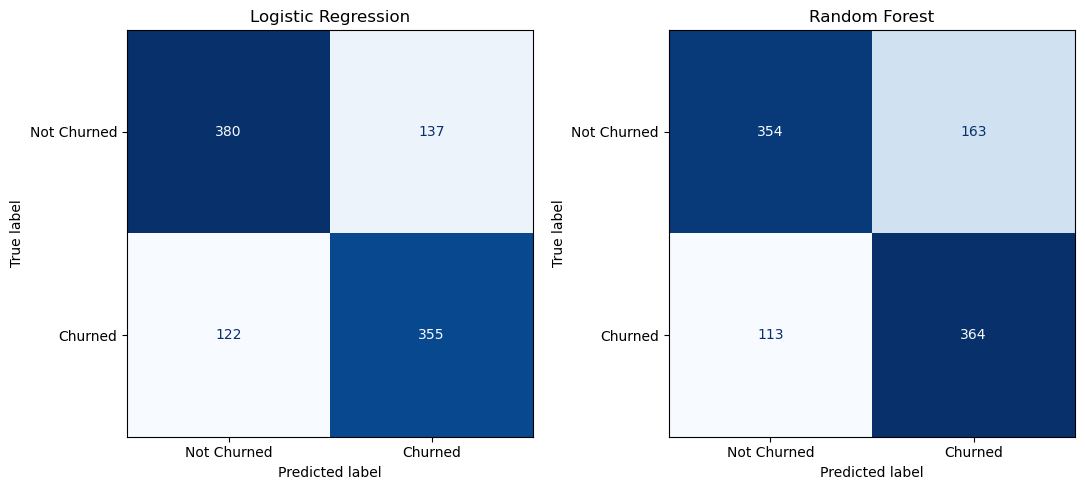

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

cm_lr = confusion_matrix(y_test, predictions)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not Churned', 'Churned'])
disp_lr.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('Logistic Regression')

cm_rf = confusion_matrix(y_test, rf_predictions)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Not Churned', 'Churned'])
disp_rf.plot(ax=axes[1], cmap='Blues', values_format='d', colorbar=False)
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.show()

### ROC Curve

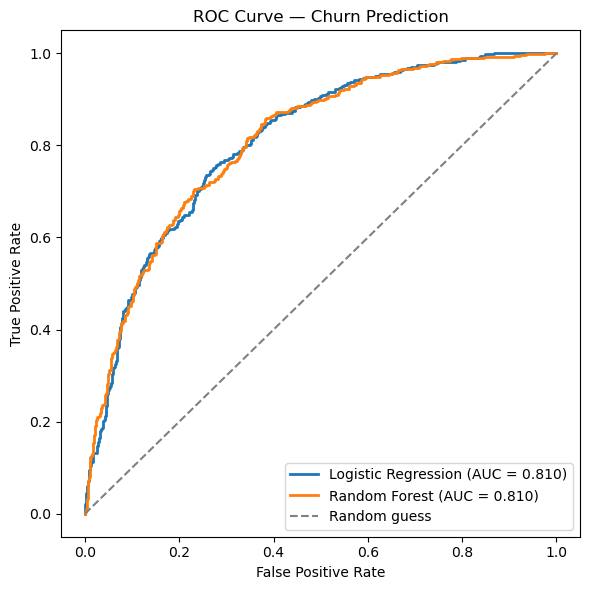

In [53]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, probabilities)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probabilities)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Churn Prediction')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Accuracy, Precision, Recall, and F1 Score

In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Logistic Regression
lr_accuracy = accuracy_score(y_test, predictions)
lr_precision = precision_score(y_test, predictions)
lr_recall = recall_score(y_test, predictions)
lr_f1 = f1_score(y_test, predictions)

print("--- Logistic Regression ---")
print("Accuracy: ", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall:   ", round(lr_recall, 4))
print("F1 Score: ", round(lr_f1, 4))

print()

# Random Forest
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("--- Random Forest ---")
print("Accuracy: ", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall:   ", round(rf_recall, 4))
print("F1 Score: ", round(rf_f1, 4))

--- Logistic Regression ---
Accuracy:  0.7394
Precision: 0.7215
Recall:    0.7442
F1 Score:  0.7327

--- Random Forest ---
Accuracy:  0.7223
Precision: 0.6907
Recall:    0.7631
F1 Score:  0.7251


### Export Churn Predictions for Power BI

In [55]:
# Build the export table using Random Forest predictions on the full X (not just test set)
# So every customer gets a churn probability, not just the 20% test split

all_probabilities = rf_model.predict_proba(X)[:, 1]

churn_export = pd.DataFrame({
    'CustomerID': rfm_churn['Customer ID'],
    'churn_probability': all_probabilities.round(4)
})

# Assign risk bands based on probability
def risk_band(prob):
    if prob >= 0.7:
        return 'High'
    elif prob >= 0.4:
        return 'Medium'
    else:
        return 'Low'

churn_export['risk_band'] = churn_export['churn_probability'].apply(risk_band)
churn_export['predicted_label'] = (churn_export['churn_probability'] >= 0.5).astype(int)

churn_export.to_csv('churn_predictions.csv', index=False)
print("Saved churn_predictions.csv —", churn_export.shape[0], "customers")
churn_export.head()

Saved churn_predictions.csv — 4966 customers


,CustomerID,churn_probability,risk_band,predicted_label
0,12346.0,0.6125,Medium,1
1,12347.0,0.1854,Low,0
2,12348.0,0.2054,Low,0
3,12349.0,0.3562,Low,0
4,12350.0,0.6823,Medium,1
